# DBSCAN Algorithm

In [32]:
import pandas as pd

df = pd.read_csv("tsne_scores.csv")
df.head()

,t-SNE-1,t-SNE-2
0,10.846841,-16.712580
1,24.794334,-16.775398
2,2.953309,13.379048
3,27.262146,-31.886690
4,-23.015728,64.468376


In [33]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4406 entries, 0 to 4405
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   t-SNE-1  4406 non-null   float64
 1   t-SNE-2  4406 non-null   float64
dtypes: float64(2)
memory usage: 69.0 KB


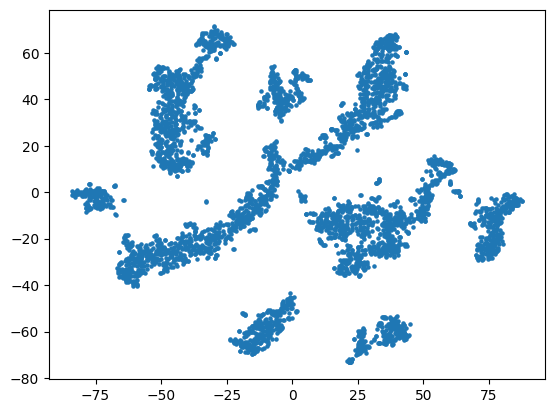

In [34]:
import matplotlib.pyplot as plt

plt.scatter(df.iloc[:,0], df.iloc[:,1], s=5)

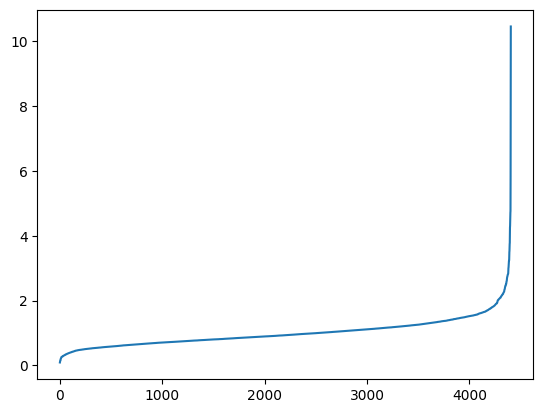

In [35]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

neighbors = NearestNeighbors(n_neighbors=4)
neighbors.fit(df)

distances, indices = neighbors.kneighbors(df)

distances = np.sort(distances[:,3])

plt.plot(distances)

In [36]:
from kneed import KneeLocator

kneedle = KneeLocator(
    range(len(distances)),
    distances,
    curve="convex",
    direction="increasing"
)

eps = distances[kneedle.knee]

In [37]:
from sklearn.cluster import DBSCAN

db = DBSCAN(
    eps=eps,
    min_samples=4
)

labels = db.fit_predict(df)

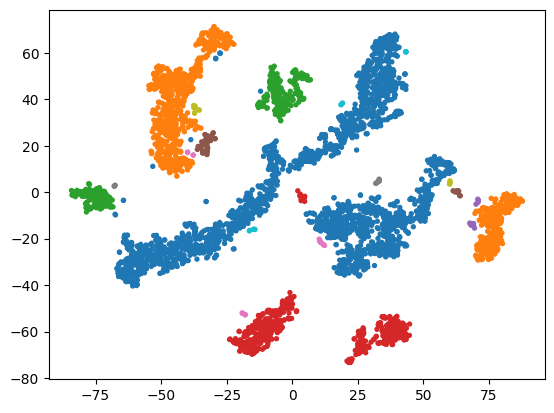

In [38]:
plt.scatter(
    df.iloc[:,0],
    df.iloc[:,1],
    c=labels,
    cmap="tab10",
    s=8
)

In [39]:
len(set(labels)) - (1 if -1 in labels else 0)

23

In [40]:
np.sum(labels==-1)

np.int64(34)

In [41]:
print(kneedle.knee)
print(eps)

4360
2.512446571811066
